#What is a Neural Network and how does it work?

A neural network is a machine learning program, or model, that makes decisions in a manner similar to the human brain, by using processes that mimic the way biological neurons work together to identify phenomena, weigh options and arrive at conclusions.

Given below is an example of a Artificial Neural Network with 3 input parameters, one hidden layer of 5 nodes and 2 output nodes.

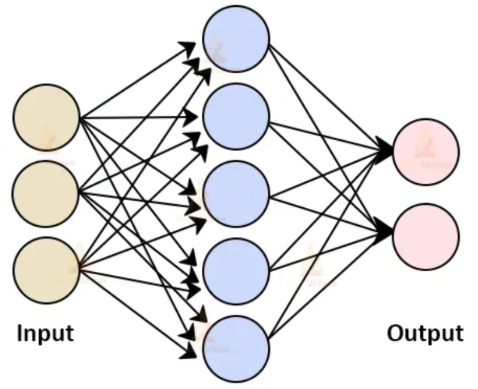

Think of each individual node as its own linear regression model, composed of input data, weights, a bias (or threshold), and an output.

The formula would look something like this:

∑wixi + bias = w1x1 + w2x2 + w3x3 + bias

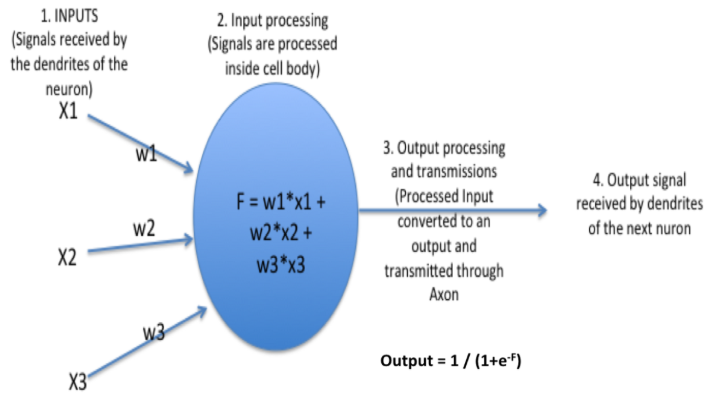

# Coding Neural Network

## Neural Network Frameworks Overview
- A framework in machine learning is a set of tools and libraries that simplify the process of building, training, and deploying neural networks.
- They are essential for efficiently managing complex neural network architectures and reducing development time.
- There are several frameworks available for coding neural networks, each with its unique strengths and use cases. Some of the most popular frameworks include:

  1. **TensorFlow**: A flexible and scalable framework developed by Google, suitable for both research and production. It excels in large-scale applications and deployment across various platforms.

  2. **Keras**: A high-level API built on TensorFlow, designed for easy model creation and rapid prototyping. Since TensorFlow 2.x, Keras has been fully integrated into TensorFlow. It is ideal for beginners and those who need a simple interface for building neural networks.
    - While TensorFlow can require low-level coding for greater flexibility, Keras provides higher-level abstractions to streamline the process, making it easier to build models and get started quickly.

  3. **PyTorch**: A dynamic and flexible framework favored for research and experimentation. It offers easy debugging and quick model iteration, making it popular in academia and research settings.

# Understanding and Loading the datasets using Tensorflow and Keras

In [ ]:
import numpy as np  # library used for numerical operations
import pandas as pd # library for data manipulation and analysis
# Importing Tensorflow and Keras library
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential # Linear stack of layers one at a time
from tensorflow.keras.layers import Dense # Fully connected layers

In [ ]:
#Import the dataset
dataset = pd.read_csv('diabetes.csv')
print(dataset.head())
print(dataset.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  ...   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35  ...  33.6                     0.627   50        1
1            1       85             66             29  ...  26.6                     0.351   31        0
2            8      183             64              0  ...  23.3                     0.672   32        1
3            1       89             66             23  ...  28.1                     0.167   21        0
4            0      137             40             35  ...  43.1                     2.288   33        1

[5 rows x 9 columns]
(768, 9)


In [ ]:
# Split the datasets into dependent and independent variables.
X = dataset.iloc[:,0:-1]
y = dataset.iloc[:,-1]
print(X)
print(y)

     Pregnancies  Glucose  BloodPressure  ...   BMI  DiabetesPedigreeFunction  Age
0              6      148             72  ...  33.6                     0.627   50
1              1       85             66  ...  26.6                     0.351   31
2              8      183             64  ...  23.3                     0.672   32
3              1       89             66  ...  28.1                     0.167   21
4              0      137             40  ...  43.1                     2.288   33
..           ...      ...            ...  ...   ...                       ...  ...
763           10      101             76  ...  32.9                     0.171   63
764            2      122             70  ...  36.8                     0.340   27
765            5      121             72  ...  26.2                     0.245   30
766            1      126             60  ...  30.1                     0.349   47
767            1       93             70  ...  30.4                     0.315   23

[76

In [ ]:
# Use sklearn library to partition the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
# Split into train and set sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)
# test_size refers to the set size of test data and random_state maintains randomness in partition

In [ ]:
model=Sequential()

model.add(Dense(5,activation='relu',input_dim=8))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6426 - loss: 0.8033 - val_accuracy: 0.6748 - val_loss: 1.1580
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6636 - loss: 0.7694 - val_accuracy: 0.6748 - val_loss: 1.1284
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6678 - loss: 0.7317 - val_accuracy: 0.6748 - val_loss: 1.1229
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6255 - loss: 0.8447 - val_accuracy: 0.6748 - val_loss: 1.1115
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6318 - loss: 0.8189 - val_accuracy: 0.6667 - val_loss: 1.1180
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6223 - loss: 0.8571 - val_accuracy: 0.6667 - val_loss: 1.0980
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6367 - loss: 0.7773 - val_accuracy: 0.6667 - val_loss: 1.0873
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6643 - loss: 0.7779 - val_accuracy: 0.6667 - v

In [ ]:
y_log=model.predict(X_test)
y_pred=np.where(y_log>=0.5,1,0)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6493506493506493

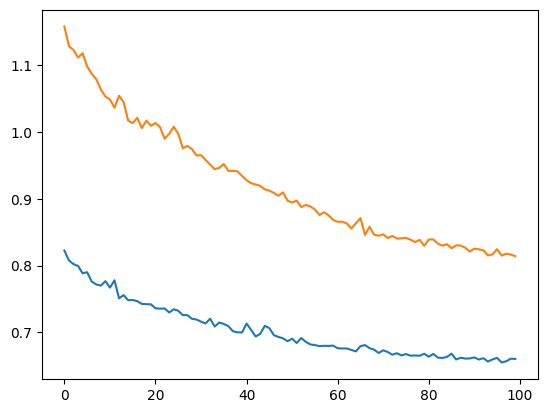

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])